# OUTLIERS

> ## What is an Outlier
An **outlier** is a data point that differs significantly form other observations. It is an anomaly that lies an abnormal distance away from other values in a random sample from a population

---
> ## Why Do Outliers Occurs
- **Simple Error**: Data entry mistakes, measurement errors, or instrument malfactions
- **Sample Anomaly**: The data point legitimately comes from the population but is extremely rare (e.g., a 7-foot-tall human)
- **Sampling from a different population**: The data point actually belongs to a different group (e.g., including adult weights in a dataset of children)
- **Structural/Novelty**: A genuine new phenomenon or shift in the system (e.g., a sudden stock market crash)

---
> ## Why Do We Care (Imapact)
- **Skew Statistics**: Outliers heavily impact the **mean** and **standard deviation** (they are non-robust). They have little effect on the **median** and **IQR** (robust)
- **Break Model Assumptions**: They violate normality, increase error variance, and reduce the power of statistical tests
- **Masking Effect**: One extreme outlier can hide another (masking), or a cluster of outliers can make normal points look like outliers (swamping)

---
> ## Types of Outliers
- **Univariate Outlier**: Extreme value in a single variable (e.g., Age = 150)
- **Multivariate Outlier**: An unusual combination of values across multiple variables, even if each individual value is normal (e.g., a 5-year-old earning $100,000/year)

---

> ## The Standard Workfollow for Handling Outliers  
- ***Detection*** (Find)
- ***Diagnosis*** (Understand why they exist)
- ***Decision*** (Choose what to do with them)

---
> ### DETECTION METHODS (The "How-To")
>
- #### Univariate Detection (Single Variable)
  - ##### Method 1: The Z-Score (Standard Score)
    - Assume data is roughly normal. Any point with a $Z-score$  beyond $\pm$  is considered an outlier
    - $$Z = \frac{x - \mu}{\sigma}$$
    - ##### Method 2: The IQR (Interquartile Range) Method (Robust, no normality assumption)
      - Uses quartiles
      - $Q_1$ = $25th$ percentile, $Q_3$ = $75th$ percentile
      - $IQR$ = $Q_3$ - $Q_1$

- #### Multivariate Detection (Multiple Variables)
  - ##### Method 3: Scatterplots and Visual Inspection
     - Plot variables against each other. Points that fall far form the main cloud are multivariate outliers
   - ##### Method 4: Mahalanobis Distance
      - Measures the distance of a point from the centroid (mean vector) of the dataset, accounting for correlations
      - Points with a p-value < 0.001 under a Chi-square distribution (with df = number of variables) are outliers
    - ##### Method 5: DBSCAN (Clustering)
       - A density-based algorithm. Points in low-density regions (no close neighbors) are labeled as outliers

---
> #### DECISION (What to do with them)
Once detected, you have **4 options**:

|**Action**|**When to Use**|
|:--------|:--------------|
|1️⃣Keep (Do nothing)|If the outlier is natural to the population and you are using  robust methods (e.g., median, quantile regression)|
|2️⃣Trim (Delete/Remove)|If it is clearly a data entry error, or if you have tens of thousands of rows and only a few oultliers|
|3️⃣Cap/Winsorize| Replace the extreme value with the nearest "non-outlier" value (e.g., set all values above the 99th percentile value)|
|4️⃣Transform|Apply log, square-root, or Box-Cox transformation ot reduce the impact of extreme values across the whole distribution|

---

## Z-Score
A **Z-score** (also called a **standard score**) tells you how many **standard deviations** a data point is away from the **mean** of its distribution  

It answers the question: "*How unusaual is this value compared to the average?*"

##### The Formula
$$Z = \frac{X - \mu}{\sigma}$$
Where:
- $X$ = the raw data value
- $\mu$ = the population
- $\sigma$ = the population standard deviation

---
##### What the Z-score Tells 
|Z-score|Meaning|
|------|--------|
|$Z = 0$|Exactly at the mean (average)|
|$Z > 0$|Above the mean (positive = above average)|
|$Z < 0$|Below the mean (negaive = below average)|
|$|Z| = 1$|1 standard deviatoin away from mean|
|$|Z| = 2$|2 standard deviation away from mean|
|$|Z| \ge 3$|Very unusaul (extreme outlier)|

---

##### The Empirical Rule (68-95-99.7 Rule)
For **normal distributions**:
- 68% of data falls within $\pm$ $1\sigma$
- 95% of data falls within $\pm$ $2\sigma$
- 99.7% of data falls within $\pm$ $3\sigma$

---

##### Why Use Z-score
- **Compare different scales** - compare apples to oranges (e.g., exam score vs. height)
- **Identify outliers** - values with $|Z| > 3$ are rare
- **Find probabilities** - using the standard normal data
- **Standardize data** - for machine learning algorithms

---

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('placement.csv')
df.shape

(1000, 3)

In [8]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


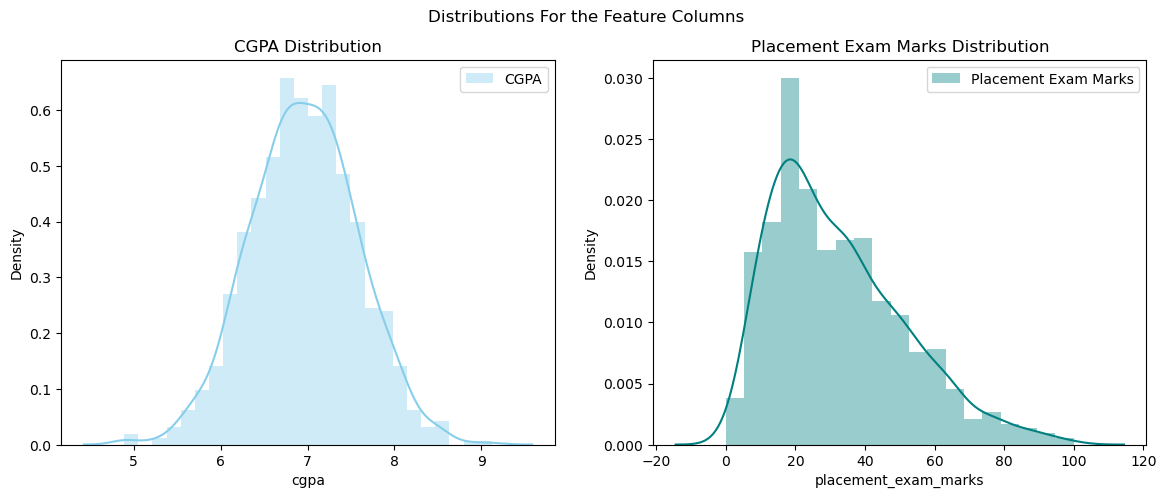

In [10]:
# Check the distribution of the feature columns

fig, axes = plt.subplots(1, 2, figsize = (14, 5))
fig.suptitle("Distributions For the Feature Columns")

sns.distplot(df['cgpa'], color = 'skyblue', label = 'CGPA', ax = axes[0])
axes[0].set_title('CGPA Distribution')
axes[0].legend()

sns.distplot(df['placement_exam_marks'], color = 'teal', label = 'Placement Exam Marks', ax = axes[1])
axes[1].set_title('Placement Exam Marks Distribution')
axes[1].legend()

plt.show()

In [14]:
# Check skewness
print(df['cgpa'].skew().round(2))
print(df['placement_exam_marks'].skew().round(2))

-0.01
0.84


In [15]:
print(f"CGPA Mean: {df['cgpa'].mean()}")
print(f"CGPA Standard Deviation: {df['cgpa'].std()}")
print(f"CGPA Minimum Value: {df['cgpa'].min()}")
print(f"CGPA Maximum Value: {df['cgpa'].max()}")

CGPA Mean: 6.96124
CGPA Standard Deviation: 0.6158978751323894
CGPA Minimum Value: 4.89
CGPA Maximum Value: 9.12


In [19]:
# Calculate mean and standard deviation
mu = df['cgpa'].mean()
sigma = df['cgpa'].std()

# Calculate lower and upper bounds - (mean +- 3sigma)
lower_bound = mu - 3*sigma
upper_bound = mu + 3*sigma

print(f"Lower bound: {lower_bound.round(2)}")
print(f"Upper bound: {upper_bound.round(2)}")

Lower bound: 5.11
Upper bound: 8.81


In [28]:
# Detect outliers
df[(df['cgpa'] < lower_bound )| (df['cgpa'] > upper_bound)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


#### Trimming (Approach 1)

In [36]:
new_df = df[(df['cgpa'] < upper_bound) & (df['cgpa'] > lower_bound)]
new_df.shape

(995, 3)

#### Z-score Method (Approach 2)

In [42]:
df['cgpa_z_score'] = (df['cgpa'] - mu) / sigma
df.head()

,cgpa,placement_exam_marks,placed,cgpa_z_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [44]:
df[(df['cgpa_z_score'] > 3) | (df['cgpa_z_score'] <- 3)]

,cgpa,placement_exam_marks,placed,cgpa_z_score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [45]:
# Trimming using Z-score
new_df = df[(df['cgpa_z_score'] > -3) & (df['cgpa_z_score'] < 3)]
new_df.shape

(995, 4)

#### Capping

In [49]:
df['cgpa'] = np.where(df['cgpa'] > upper_bound, upper_bound, np.where(df['cgpa'] < lower_bound, lower_bound, df['cgpa']))
df.shape

(1000, 4)

In [50]:
df.cgpa.describe().T

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

#### Using Module

In [51]:
from scipy import stats
from feature_engine.outliers import Winsorizer, OutlierTrimmer

In [52]:
df = pd.read_csv('placement.csv')
df.shape

(1000, 3)

In [53]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [55]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cgpa,1000.0,6.96124,0.615898,4.89,6.55,6.96,7.37,9.12
placement_exam_marks,1000.0,32.22500,19.130822,0.00,17.00,28.00,44.00,100.00
placed,1000.0,0.48900,0.500129,0.00,0.00,0.00,1.00,1.00


In [56]:
df.isnull().mean()

cgpa                    0.0
placement_exam_marks    0.0
placed                  0.0
dtype: float64

#### Method 1 - Quick Z-Score with SciPy

In [65]:
def detect_outliers_zscore(data, column, threshold = 3):
    """
        Detect outliers using Z-Score method
    """

    # Calculate Z-scores
    z_score = np.abs(stats.zscore(data[column]))

    # Identify Outliers
    outliers = z_score > threshold
    outlier_indices = np.where(outliers)[0]

    # Get Outlier values
    outlier_values = data[column].iloc[outlier_indices]

    return outliers, outlier_values


In [66]:
# Detect outliers in CGPA
outliers, outlier_indices = detect_outliers_zscore(df, 'cgpa')

In [68]:
df_trimmed = df[~outliers]
df_trimmed.shape

(995, 3)

In [69]:
df_trimmed.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [71]:
# cappig
def cap_outlier_zscore(data, column, threshold = 3):
    lower_limit = data[column].mean() - threshold * data[column].std()
    upper_limit = data[column].mean() + threshold * data[column].std()

    data_capped = data.copy()
    data_capped[column] = np.where(
        data_capped[column] > upper_limit,
        upper_limit,
        np.where(
            data_capped[column] < lower_limit,
            lower_limit,
            data_capped[column]
        )
    
    )
    return data_capped

In [72]:
df_capped = cap_outlier_zscore(df, 'cgpa')
df_capped.shape

(1000, 3)

In [73]:
df_capped.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


#### Method 2 - Feature-engine

In [74]:
# Trimming
trimmer = OutlierTrimmer(
    capping_method='gaussian', # use mean +- 3sigma
    tail = 'both', # cap both sides
    fold = 3, # number of standard deviation
    variables = ['cgpa'] # columns to apply
)
trimmer.set_output(transform = 'pandas')
df_trimmed = trimmer.fit_transform(df)

In [75]:
df_trimmed.shape

(995, 3)

In [78]:
df.shape[0] - df_trimmed.shape[0]

5

In [80]:
# Capping - Winsorizer
winsorizer = Winsorizer(
    capping_method = 'gaussian',
    tail = 'both',
    fold = 3,
    variables = ['cgpa']
)

winsorizer.set_output(transform = 'pandas')
df_capped = winsorizer.fit_transform(df)

In [82]:
df_capped.shape

(1000, 3)

In [83]:
df['cgpa'].describe().T

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

In [84]:
df_capped['cgpa'].describe().T

count    1000.000000
mean        6.961499
std         0.612674
min         5.114470
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808010
Name: cgpa, dtype: float64